In [33]:
%matplotlib inline

In [34]:
import numpy as np
import matplotlib.pyplot as plt


# Draw samples from a poissonian distribution
sample_1 = np.random.poisson(5,100) 
sample_2 = np.random.poisson(5,100)

In [35]:
sample_1

array([ 6,  5,  4,  6,  4,  4,  7,  7,  6,  3,  5,  9,  2,  6,  9,  4,  3,
        3,  3,  6,  6,  1,  5,  3,  4,  5,  4,  2,  6,  4,  7,  3,  6,  7,
        4,  7,  7,  6,  7,  3,  7,  8,  5,  5,  4,  6,  4,  2,  6,  7,  3,
        3,  5,  8,  9,  9,  5,  3,  3, 11,  6,  3,  7,  2,  6,  4,  4,  4,
        6,  5,  4,  3,  5,  4,  7,  5,  5,  6,  7,  6, 12,  6,  5,  6,  4,
        2,  8,  2,  5,  2,  5,  5,  5,  3,  7,  7,  5,  6,  5,  8])

What we have now is two 100-point long lists that contain the amount of times your detector dinged every five seconds for 500 seconds. We want to combine this data then convert it to a frequency chart. First, let's combine:

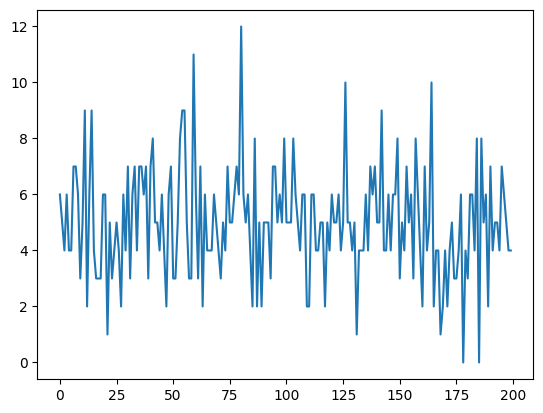

In [55]:
samples = np.concatenate((sample_1,sample_2)) # Combine the two samples together into one big list
plt.plot(samples)

In [56]:
# By putting the number of bins to be the maximum of our data, we generate a bin for every integer
freqs, bins = np.histogram(samples, bins=np.max(samples), range=(0,np.max(samples)))


In [38]:
bin_centers = 0.5*(bins[1:]+bins[:-1]) # Adding the left edge and right edge together and then dividing by 2

In [39]:
bin_centers

array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
       11.5])

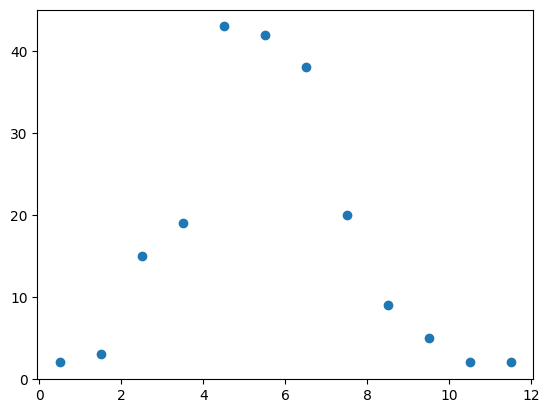

In [40]:
plt.scatter(bin_centers,freqs)

In [41]:
import scipy.optimize as opt
from scipy.special import factorial # NumPy's factorial doesn't work here. Can you figure out why?

# Take out zero bins. The discussion for why I do this is beyond the scope of this intro, ask the instructors
# It's not important to know what's going on in this function if you don't want to know.
# If you do want to know, you'll have to think about it
def delete_zeros(bins,counts,err):
    '''
    Inputs:
    bins = the frequency bin centers
    counts = the frequency data
    err = the error data
    Output:
    new_bins = bin centers, but if the frequency of a bin center is zero the bin is removed
    new_counts = frequency data, but if "                    "
    new_err = error data, but if "                       "
    '''
    zeros = np.where(counts==0) # Find the indices where the frequency data is zero
    mask = np.ones(len(counts),dtype=bool) # create a mask of True values
    mask[zeros[0]] = False # Turn the zero parts of the mask False
    new_counts = counts[mask] # Recreate the bin data without the False parts
    new_bins = bins[mask] # Recreate the frequency data without the False parts
    new_err = err[mask] # Recrete the "      "
    return new_bins, new_counts, new_err
    
def poisson(x,lam,a):
    '''
    Inputs:
    a = normalization constant
    x = corresponding number of events, should be an array
    lam = expected value, which is equal to the variance for poisson distribution
    Outputs: probability of x number of events occuring, scaled by constant a
    '''
    return a*lam**x*np.exp(-lam)/factorial(x)

bin_centers, freqs, sig = delete_zeros(bin_centers, freqs, np.sqrt(freqs)) # Take out the zeros from our data
popt, pcov = opt.curve_fit(f=poisson, xdata=bin_centers, ydata=freqs, sigma=sig, p0=[5,200], absolute_sigma=True) # Fit function
uncert = np.sqrt(np.diag(pcov)) # Extract uncertainty from fit

What we have now is a estimate of the value of `a` and `lam` (again, read the documentation to understand this) as well as the uncertainty in these two variables in our array `uncert`:

In [42]:
print(popt)
print(uncert)

[  5.57068899 179.70294602]
[ 0.15811513 13.46627694]


How closely does our estimate match up with the data? 

<ErrorbarContainer object of 3 artists>

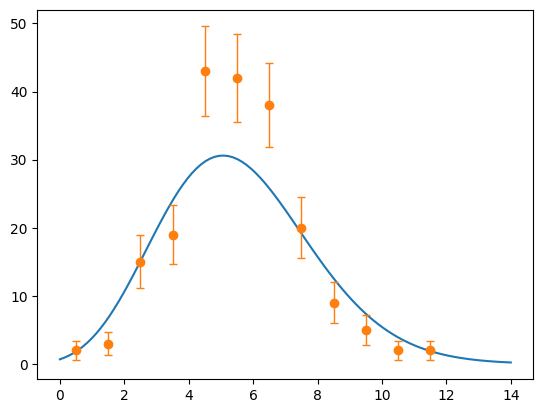

In [43]:
x = np.linspace(start=0,stop=14,num=100,endpoint=True) # Define x for smoother plotting of our poisson fit function

plt.plot(x, poisson(x, popt[0], popt[1])) # Plot fit function
# If you have a bunch of arguments in popt, you're better off using *popt instead of listing out each popt variabe:
# If you don't know what the * does, quickly google it.
# plt.plot(x, poisson(x,*popt))

plt.errorbar(bin_centers, freqs, yerr=sig, linewidth=1, ls='none', fmt='o', capsize=3) # Plot actual data

Unfortunately, curve_fit does not immediately come with an option to print out the $\chi^2$ value. We'll have to calculate that by hand (the package LMFIT for Python does have this capability, I suggest trying that out if you want).

In [44]:
def chisq(func,popt,x,y,sig):
    '''
    Inputs:
    func = function to generate expected value
    x = x data
    y = y data
    sig = sigma data
    Outputs:
    chi2 = chi-squared value
    '''
    expected_vals = func(x, *popt) # Again, better off using *popt
    return np.sum((y-expected_vals)**2/sig**2)

chi2 = chisq(poisson,popt,bin_centers,freqs,sig)
chi2

np.float64(21.845271766761375)

So, we have a calculated $\chi^2$. What is our corresponding $\chi^2$ probability? First, we gotta figure out our degrees of freedom:

In [45]:
dof = len(bin_centers) - 2 # Our degrees of freedom is equal to the number of data points minus the number of fit parameters

dof

10

In [46]:
from scipy import stats

chi2_probs = 1 - stats.chi2.cdf(chi2,dof) # Get the probability by subtracting 1 from the cumulative distribution function

chi2_probs

np.float64(0.015912541579464312)

So, we've got data points and a pretty graph. It makes sense that we would probably want to export the data so we can read it in later, and the graph could go on our LaTeX reports. How do we do that?

Let's start with the data. Let's first try to export the locations of the bin centers, the frequencies associated with them, and the error on the associated frequencies. In order to put them all into the same file, we'll throw them into a single dictionary with associated names:

In [47]:
data_prelim = {'bin_centers':bin_centers, 'freqs':freqs, 'error':sig} # Create dictionary of data with names as the keys

data_prelim

{'bin_centers': array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5]),
 'freqs': array([ 2,  3, 15, 19, 43, 42, 38, 20,  9,  5,  2,  2]),
 'error': array([1.41421356, 1.73205081, 3.87298335, 4.35889894, 6.55743852,
        6.4807407 , 6.164414  , 4.47213595, 3.        , 2.23606798,
        1.41421356, 1.41421356])}

There are many ways to a solution here. There is a Python package called `csv` that you are free to figure out. For this notebook, we are going to be using the immense Pandas package. Pandas is a popular data science package for Python. It's recommended (but not really required like the other packages) that you learn how to use it. For this demonstration, we'll be learning how to use Pandas to export and import csv files. CSV stands for "comma separated values." Essentially, your data is being stored as a plain text file in a certain way, which is specified with delimiters. In the default case, our delimiter is a comma, hence the name.

First, we'll import the package:

In [48]:
import pandas as pd

We'll convert the numpy array into what Pandas uses: a DataFrame

In [49]:
data_to_export = pd.DataFrame(data_prelim) # Convert dic of NumPy arrays into a Pandas DataFrame

data_to_export

,bin_centers,freqs,error
0,0.5,2,1.414214
1,1.5,3,1.732051
2,2.5,15,3.872983
3,3.5,19,4.358899
4,4.5,43,6.557439
5,5.5,42,6.480741
6,6.5,38,6.164414
7,7.5,20,4.472136
8,8.5,9,3.000000
9,9.5,5,2.236068


The cool formatting is all Pandas. It's a very powerful program. Now, this looks good to export. Let's let Pandas do the work:

In [50]:
data_to_export.to_csv('example.csv', index=False) # the index=False tag makes sure that the leftmost column is not written

You should now be able to see a csv file called `example.csv` in the same folder as this jupyter notebook. Of course, you could always specify the path that you want to save this csv to. Instead of just putting the name, we can instead do `'Path\to\File\Filename.csv'`.

You can open the csv for yourself and see how exactly the csv was saved. It looks a little weird. Essentially (and this is only because we didn't set any special method for delimiters or line endings, so Pandas just uses these setting by default), our data is being written to this file row by row, using a comma to separate the values. Once the row is done, we signal the end of it with a line_terminator, in this case it's a `newline` command.

***Note:*** It's not important to totally understand how a csv file and other files of this type look right now, but it will become important once you start exporting data from your experiments. Some of your data will not be exported in an elegant way, and it will be up to you to figure out how to finagle your csv reading program to get it to import to Python correctly ("I'm looking at you, 21cm..."). 

For now, let's just check that we can re-read out data and make sure it looks legible. Pandas has the ability to read in csv's, too:

In [51]:
data_reread = pd.read_csv('example.csv')

data_reread

,bin_centers,freqs,error
0,0.5,2,1.414214
1,1.5,3,1.732051
2,2.5,15,3.872983
3,3.5,19,4.358899
4,4.5,43,6.557439
5,5.5,42,6.480741
6,6.5,38,6.164414
7,7.5,20,4.472136
8,8.5,9,3.000000
9,9.5,5,2.236068


Cool, now our data is saved. You can access individual columns by slicing with the name of the column:

In [52]:
data_reread['bin_centers']

# can also use data_reread.loc[:, 'bin_centers']
# can also use data_reread.bin_centers

0      0.5
1      1.5
2      2.5
3      3.5
4      4.5
5      5.5
6      6.5
7      7.5
8      8.5
9      9.5
10    10.5
11    11.5
Name: bin_centers, dtype: float64

If, for some reason, we don't have a name and don't want to give the columns a name, we can just index with an integer as well:

In [53]:
data_reread.iloc[:, 0] # All rows, column 0

0      0.5
1      1.5
2      2.5
3      3.5
4      4.5
5      5.5
6      6.5
7      7.5
8      8.5
9      9.5
10    10.5
11    11.5
Name: bin_centers, dtype: float64

What about the pretty plot that we made earlier? We want to save that too. Matplotlib has the ability to save plots that you generate with its `savefig` command:

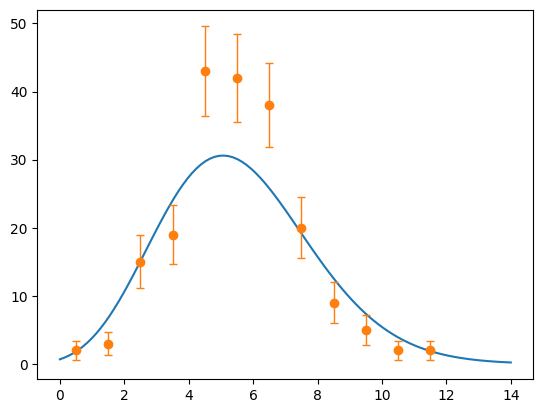

In [54]:
plt.plot(x, poisson(x, *popt)) # Plot fit function
plt.errorbar(bin_centers, freqs, yerr=sig, linewidth=1, ls='none', fmt='o', capsize=3) # Plot actual data

plt.savefig('example_plot.png')

Now, you have the above plot saved to your machine in the same place as your notebook. Of course, you can always change the path that this plot is saved by modifying the file name to include the path: `'Path\to\File\Filename.png'`.

# Optional: Upload your work to GitHub

It's always a good idea to upload your work somewhere that's not on a local machine. You could choose to just upload things to a Google Drive or something like that, but github offers superior source control. At some point, you'll probably break your code, and most likely you won't know what your previous version of code was like. If you've coded before, you'll know the pain of spending a long time trying to figure out what you changed. GitHub can help you with that. Trust me, put a little bit of time into the insurance now and you'll be a lot better off in the long run.

Once you know the basics, it's actually pretty easy. Actually, no coding is required!

GitHub has tons of tutorials that you can use to familiarize yourself:

- [Hello World: Creating you First Repo and Modifying It](https://guides.github.com/activities/hello-world/)
- [Getting Started with GitHub](https://docs.github.com/en/github/getting-started-with-github)
- For those of you that want to use a bash terminal, [here is a startup guide](https://git-scm.com/book/en/v2/Getting-Started-The-Command-Line)
- Windows users can also download the [GitHub Desktop app](https://desktop.github.com/)

If you don't want to use github, upload it *somewhere*, whether it's Dropbox, Google Drive, or whatever other file hosting website you want to use. An excellent choice would be [MIT's Enterprise GitHub](https://github.mit.edu/).